# 01 - Chargement et analyse exploratoire du dataset RH

## Introduction

Dans cette première étape du projet **Employee Attrition Prediction - RH**, l'objectif est de charger le dataset RH et de réaliser une analyse exploratoire initiale.

Cette analyse permet de comprendre la structure générale des données, d'identifier les types de variables disponibles, de vérifier la présence de valeurs manquantes ou de doublons, puis d'étudier la variable cible **Attrition**. Cette étape prépare la suite du projet, qui portera sur le nettoyage des données et le prétraitement.

## 1. Importation des bibliothèques

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Chargement du dataset

In [64]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Interprétation :** Cette première visualisation permet d'avoir un aperçu général des colonnes du dataset et des premières observations. Elle aide à comprendre rapidement la forme des données avant de réaliser des analyses plus détaillées.

## 3. Dimensions du dataset

In [65]:
df.shape

(1470, 35)

**Interprétation :** La commande `df.shape` permet d'afficher les dimensions du dataset. Le premier nombre correspond au nombre de lignes, c'est-à-dire le nombre d'employés observés. Le deuxième nombre correspond au nombre de colonnes, c'est-à-dire le nombre de variables disponibles pour décrire chaque employé.

## 4. Liste des colonnes

In [66]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

**Interprétation :** Cette étape permet d'identifier les variables disponibles dans le dataset. On peut ainsi repérer les informations liées au profil de l'employé, à son poste, à sa rémunération, à sa satisfaction et à la variable cible **Attrition**.

## 5. Informations générales sur le dataset

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Interprétation :** La méthode `df.info()` permet de voir les types des variables et le nombre de valeurs non nulles pour chaque colonne. Elle est utile pour repérer les variables numériques, les variables catégorielles et la présence éventuelle de valeurs manquantes.

## 6. Vérification des valeurs manquantes

In [68]:
missing_values = df.isnull().sum()
missing_values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

**Interprétation :** Cette vérification permet de savoir si certaines colonnes contiennent des valeurs manquantes. Si toutes les valeurs affichées sont égales à 0, cela signifie que le dataset ne contient pas de valeurs manquantes apparentes. Dans le cas contraire, il faudra traiter ces valeurs dans l'étape de nettoyage.

## 7. Vérification des doublons

In [69]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

**Interprétation :** Les doublons correspondent à des lignes répétées dans le dataset. Ils peuvent influencer l'analyse en donnant trop de poids à certains employés ou à certaines situations. Il est donc important de les identifier avant les étapes de nettoyage et de modélisation.

## 8. Statistiques descriptives des variables numériques

In [70]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Interprétation :** Les statistiques descriptives permettent de comprendre les valeurs moyennes, minimales, maximales et la dispersion des variables numériques. Cette étape aide à repérer les ordres de grandeur des variables et à avoir une première idée de leur distribution.

## 9. Identification des variables numériques et catégorielles

In [71]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Nombre de variables numériques : {len(numeric_columns)}")
print(f"Nombre de variables catégorielles : {len(categorical_columns)}")

print("\nVariables numériques :")
print(numeric_columns)

print("\nVariables catégorielles :")
print(categorical_columns)

Nombre de variables numériques : 26
Nombre de variables catégorielles : 9

Variables numériques :
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Variables catégorielles :
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**Interprétation :** Cette étape permet de séparer les variables numériques des variables catégorielles. Les variables catégorielles, comme le département ou le rôle du poste, devront être encodées plus tard avant l'entraînement des modèles de Machine Learning.

## 10. Analyse de la variable cible Attrition

In [72]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [73]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

**Interprétation :** La variable **Attrition** est la variable cible du projet. Elle indique si un employé a quitté l'entreprise (**Yes**) ou non (**No**).

On observe que la classe **No** est majoritaire, tandis que la classe **Yes** est minoritaire. Le dataset est donc déséquilibré. Cela signifie que l'accuracy seule ne sera pas suffisante pour évaluer les futurs modèles, car un modèle pourrait obtenir une bonne accuracy en prédisant surtout la classe majoritaire. Pour une évaluation plus fiable, il faudra aussi utiliser des métriques comme la **precision**, le **recall** et le **F1-score**.

## 11. Distribution de la variable Attrition

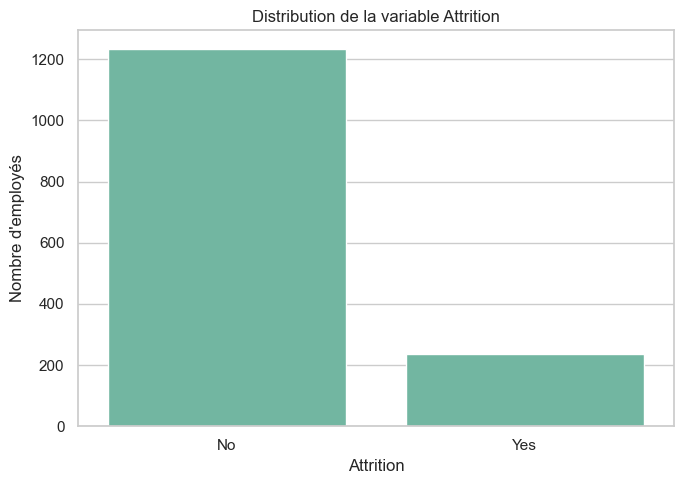

In [74]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Attrition", order=["No", "Yes"])
plt.title("Distribution de la variable Attrition")
plt.xlabel("Attrition")
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.savefig("../results/figures/attrition_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Le graphique confirme que les employés qui ne quittent pas l'entreprise sont beaucoup plus nombreux que ceux qui la quittent. Cette différence montre visuellement le déséquilibre de la variable cible.

## 12. Analyse de l'Attrition selon certaines variables

### 12.1 Attrition selon les heures supplémentaires

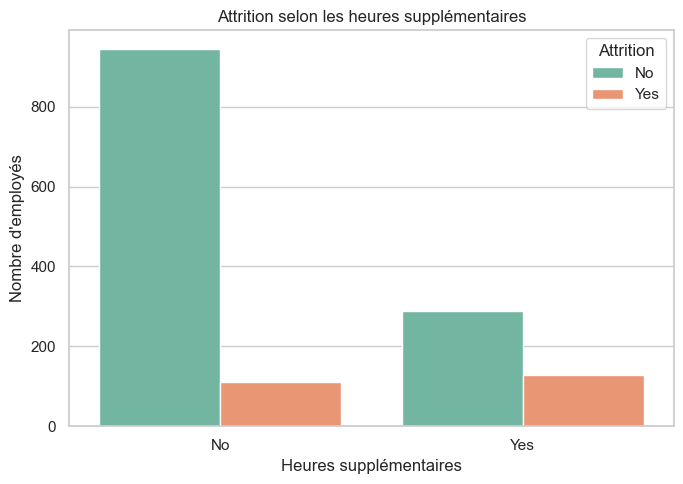

In [75]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="OverTime", hue="Attrition", order=["No", "Yes"], hue_order=["No", "Yes"])
plt.title("Attrition selon les heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Nombre d'employés")
plt.legend(title="Attrition")
plt.tight_layout()
plt.savefig("../results/figures/attrition_by_overtime.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Ce graphique permet de comparer l'attrition entre les employés qui font des heures supplémentaires et ceux qui n'en font pas. Une proportion plus élevée de départs chez les employés en heures supplémentaires peut indiquer que la charge de travail influence le risque de départ.

### 12.2 Attrition selon le département

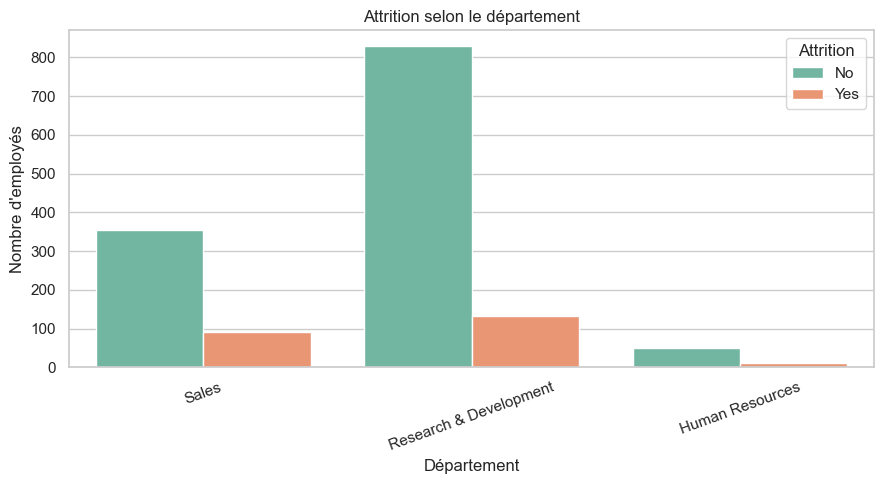

In [76]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Department", hue="Attrition", hue_order=["No", "Yes"])
plt.title("Attrition selon le département")
plt.xlabel("Département")
plt.ylabel("Nombre d'employés")
plt.legend(title="Attrition")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../results/figures/attrition_by_department.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Ce graphique montre la répartition des départs selon les départements. Il permet d'observer si certains départements semblent plus concernés par l'attrition que d'autres, ce qui peut orienter les analyses suivantes.

### 12.3 Attrition selon le rôle du poste

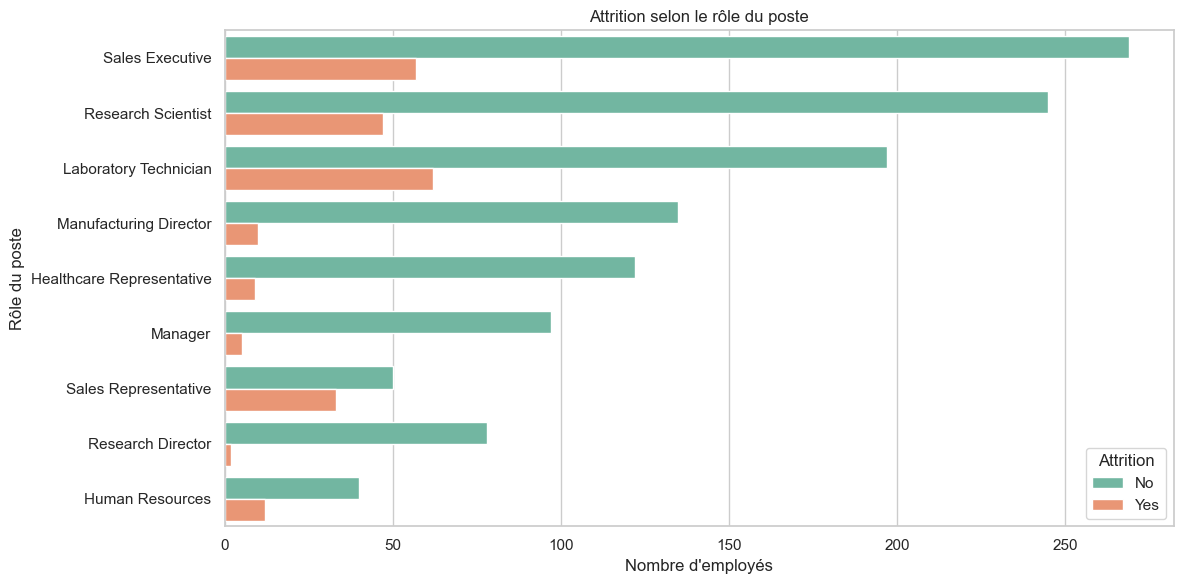

In [77]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y="JobRole", hue="Attrition", hue_order=["No", "Yes"], order=df["JobRole"].value_counts().index)
plt.title("Attrition selon le rôle du poste")
plt.xlabel("Nombre d'employés")
plt.ylabel("Rôle du poste")
plt.legend(title="Attrition")
plt.tight_layout()
plt.savefig("../results/figures/attrition_by_job_role.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** L'analyse par rôle de poste permet de voir si certains métiers présentent davantage de cas d'attrition. Cette information peut être utile pour comprendre les catégories d'employés les plus exposées au départ.

### 12.4 Attrition selon la satisfaction au travail

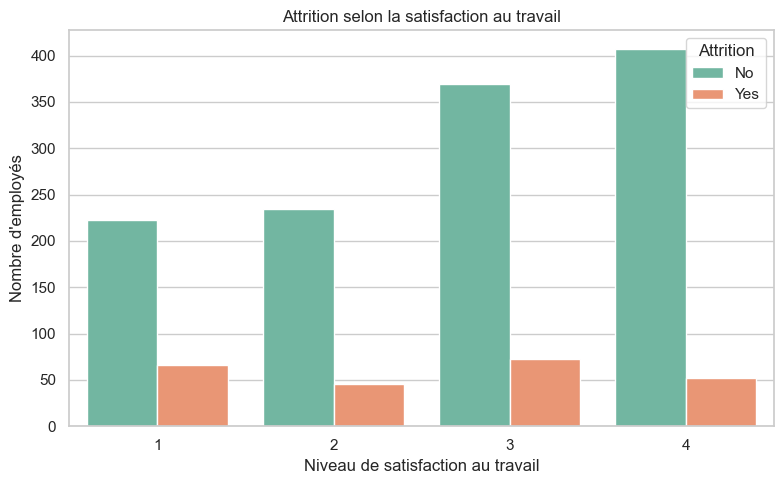

In [78]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", hue_order=["No", "Yes"])
plt.title("Attrition selon la satisfaction au travail")
plt.xlabel("Niveau de satisfaction au travail")
plt.ylabel("Nombre d'employés")
plt.legend(title="Attrition")
plt.tight_layout()
plt.savefig("../results/figures/attrition_by_job_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Ce graphique permet d'étudier le lien entre la satisfaction au travail et l'attrition. En général, un niveau de satisfaction plus faible peut être associé à un risque plus élevé de départ, même si cette relation devra être confirmée par des analyses plus approfondies.

## 13. Analyses exploratoires complémentaires liées à Attrition

Dans cette partie, on ajoute quelques analyses simples pour mieux comprendre les relations possibles entre certaines variables numériques et la variable cible **Attrition**. Ces analyses restent exploratoires : elles ne constituent pas encore une étape de modélisation.

### 13.1 Distribution du revenu mensuel selon Attrition

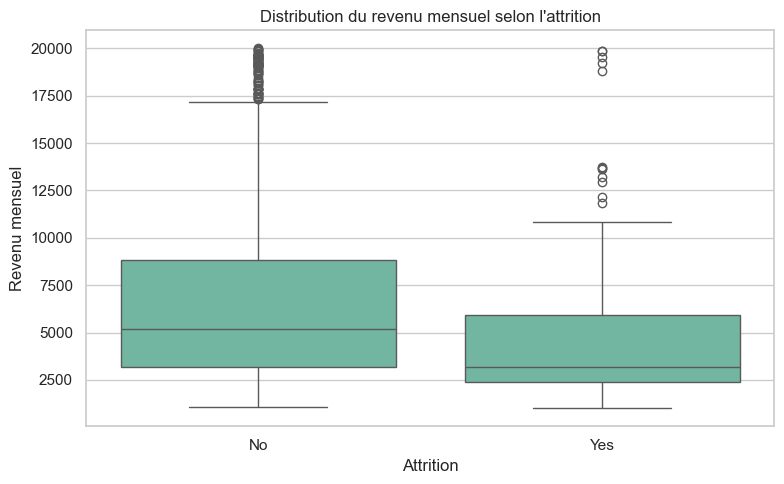

In [79]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["No", "Yes"])
plt.title("Distribution du revenu mensuel selon l'attrition")
plt.xlabel("Attrition")
plt.ylabel("Revenu mensuel")
plt.tight_layout()
plt.savefig("../results/figures/monthly_income_by_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Ce boxplot permet de comparer le revenu mensuel des employés qui restent avec celui des employés qui quittent l’entreprise. Dans ce dataset, les employés avec **Attrition = Yes** ont tendance à avoir un revenu mensuel plus faible que ceux avec **Attrition = No**. Cela peut indiquer que le niveau de rémunération est une variable intéressante à analyser dans la suite du projet.

### 13.2 Distribution de l’âge selon Attrition

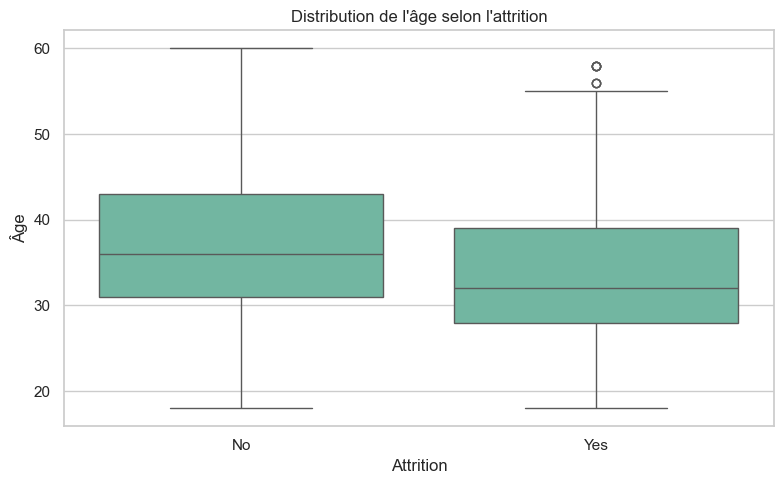

In [80]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="Age", order=["No", "Yes"])
plt.title("Distribution de l'âge selon l'attrition")
plt.xlabel("Attrition")
plt.ylabel("Âge")
plt.tight_layout()
plt.savefig("../results/figures/age_by_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Ce boxplot montre la distribution de l’âge selon la situation d’attrition. On observe que les employés qui quittent l’entreprise semblent généralement plus jeunes que ceux qui restent. Cette différence d’âge peut être une piste exploratoire importante, même si elle ne suffit pas à expliquer seule le départ des employés.

### 13.3 Corrélation des variables numériques avec Attrition

In [81]:
df_corr = df.copy()
df_corr["Attrition_num"] = df_corr["Attrition"].map({"No": 0, "Yes": 1})

numeric_corr_columns = df_corr.select_dtypes(include=[np.number]).columns
correlation_with_attrition = (
    df_corr[numeric_corr_columns]
    .corr()["Attrition_num"]
    .drop("Attrition_num")
    .sort_values()
)

correlation_table = correlation_with_attrition.reset_index()
correlation_table.columns = ["Variable", "Corrélation avec Attrition"]
correlation_table

,Variable,Corrélation avec Attrition
0,TotalWorkingYears,-0.171063
1,JobLevel,-0.169105
2,YearsInCurrentRole,-0.160545
3,MonthlyIncome,-0.159840
4,Age,-0.159205
5,YearsWithCurrManager,-0.156199
6,StockOptionLevel,-0.137145
7,YearsAtCompany,-0.134392
8,JobInvolvement,-0.130016
9,JobSatisfaction,-0.103481


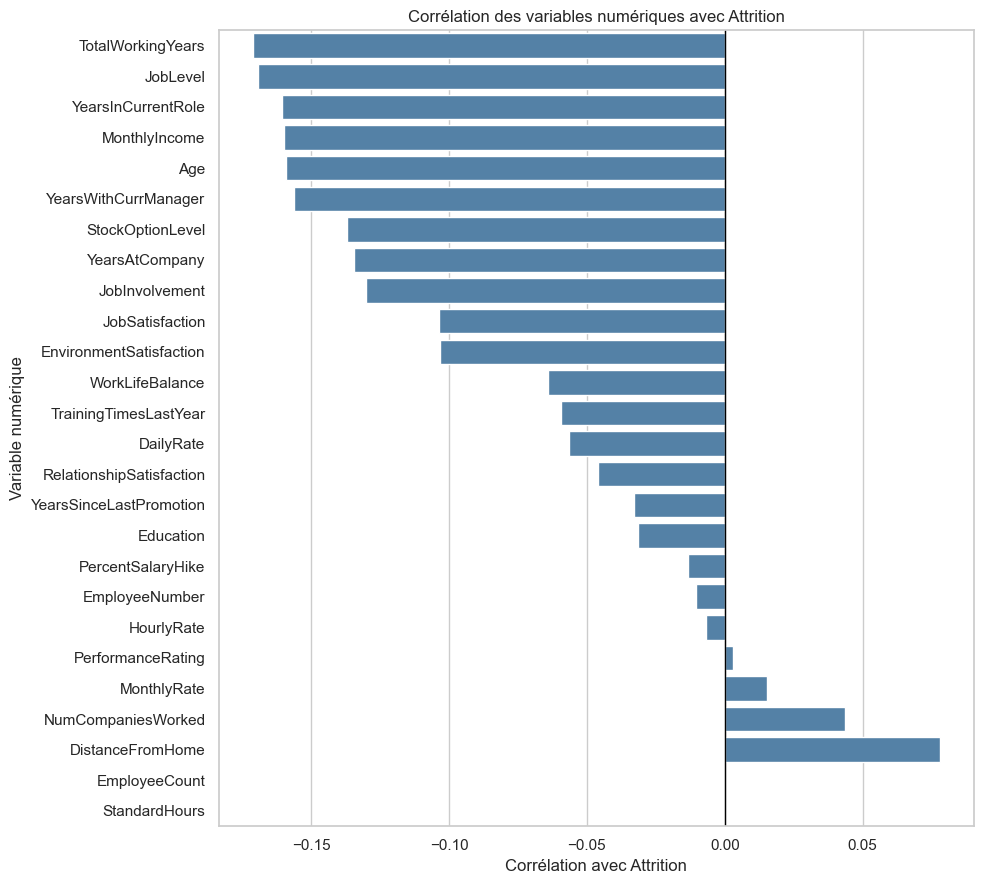

In [82]:
plt.figure(figsize=(10, 9))
sns.barplot(
    data=correlation_table,
    x="Corrélation avec Attrition",
    y="Variable",
    color="steelblue"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Corrélation des variables numériques avec Attrition")
plt.xlabel("Corrélation avec Attrition")
plt.ylabel("Variable numérique")
plt.tight_layout()
plt.savefig("../results/figures/correlation_with_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** Cette analyse montre la corrélation entre les variables numériques et la variable cible transformée en variable numérique, où **Yes = 1** et **No = 0**.

Une corrélation positive signifie que lorsque la variable augmente, le risque d’attrition a tendance à augmenter aussi. Une corrélation négative signifie que la variable a tendance à diminuer lorsque le risque d’attrition augmente. Une corrélation proche de 0 indique une relation linéaire faible entre la variable et l’attrition.

Cette analyse donne seulement une indication exploratoire sur les relations possibles entre les variables et **Attrition**. Elle ne prouve pas une causalité et ne remplace pas une analyse plus approfondie ou une étape de modélisation future.

## Conclusion partielle

Dans ce notebook, le dataset RH a été chargé correctement à partir du fichier CSV fourni. La variable cible du projet est **Attrition**, qui indique si un employé quitte ou non l'entreprise.

L'analyse exploratoire initiale montre que le dataset contient à la fois des variables numériques et des variables catégorielles. Les variables catégorielles devront être traitées plus tard dans l'étape de prétraitement.

La variable **Attrition** est déséquilibrée : la majorité des employés appartient à la classe **No**, tandis que la classe **Yes** est minoritaire. Ce point sera important pour l'évaluation des futurs modèles, car l'accuracy seule ne suffira pas.

Les premiers graphiques donnent une première idée des facteurs qui peuvent influencer le départ des employés, comme les heures supplémentaires, le département, le rôle du poste ou la satisfaction au travail.

La prochaine étape du projet sera le **nettoyage des données** et le **prétraitement**, sans encore passer directement à la modélisation.